# Preprocesamiento Completo - Statlog (Australian Credit Approval)

En este cuaderno hago el flujo completo del dataset, paso por paso, como en clase:
1. Carga y revisión de datos
2. Split 75/25
3. Manejo de nulos
4. Codificación
5. Normalización con `featureNormalize`
6. Balanceo del train
7. Preparación final
8. Modelo de regresión lineal
9. Modelo de clasificación logística

## 1. Importación de Librerías

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import torch
from sklearn.preprocessing import LabelEncoder
from scipy import optimize
from IPython.display import display

%matplotlib inline

## Paso 1: Carga del dataset

Se carga `australian.dat`. La variable objetivo es `A15` (1 = crédito aprobado, 0 = rechazado).
Los valores `?` se tratan como nulos para manejarlos en el paso 3.

In [2]:
ruta_archivo = os.path.join(
    'Datasets Primer Parcial',
    '7-Statlog (Australian Credit Approval)',
    'statlog+australian+credit+approval',
    'australian.dat',
)

columnas = [f'A{i}' for i in range(1, 16)]
df = pd.read_csv(
    ruta_archivo,
    sep=r'\s+',
    header=None,
    names=columnas,
    na_values='?',
    skipinitialspace=True,
    engine='python',
)

print('Dimensiones originales:', df.shape)
print('Primeras filas:')
display(df.head())
print('Tipos de dato:')
print(df.dtypes)
print('Nulos por columna:')
print(df.isnull().sum())

Dimensiones originales: (690, 15)
Primeras filas:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


Tipos de dato:
A1       int64
A2     float64
A3     float64
A4       int64
A5       int64
A6       int64
A7     float64
A8       int64
A9       int64
A10      int64
A11      int64
A12      int64
A13      int64
A14      int64
A15      int64
dtype: object
Nulos por columna:
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
dtype: int64


## Paso 2: División 75/25

Tomé `A15` como variable objetivo y separé 75% para entrenamiento y 25% para prueba.

Esta parte es importante porque el test se deja aparte para evaluar al final con datos que el modelo no vio antes.

In [3]:
target_col   = 'A15'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

torch.manual_seed(42)

n_total = X.shape[0]
n_test  = int(0.25 * n_total)
n_train = n_total - n_test

indices       = torch.randperm(n_total).tolist()
train_indices = indices[:n_train]
test_indices  = indices[n_train:]

X_train_raw = X.iloc[train_indices].copy()
y_train_raw = y.iloc[train_indices].copy()
X_test_raw  = X.iloc[test_indices].copy()
y_test_raw  = y.iloc[test_indices].copy()

print(f'Train: {len(X_train_raw)}/{n_total} ({len(X_train_raw)/n_total*100:.1f}%)')
print(f'Test : {len(X_test_raw)}/{n_total} ({len(X_test_raw)/n_total*100:.1f}%)')
print('Distribucion en train (y):')
print(y_train_raw.value_counts().sort_index())
print('Distribucion en test (y):')
print(y_test_raw.value_counts().sort_index())

Train: 518/690 (75.1%)
Test : 172/690 (24.9%)
Distribucion en train (y):
A15
0    289
1    229
Name: count, dtype: int64
Distribucion en test (y):
A15
0    94
1    78
Name: count, dtype: int64


## Paso 3: Manejo de valores nulos

Para no perder filas, rellené nulos así:
- Numéricas con la media del train
- Categóricas con la moda del train

Lo hice usando solo train para evitar fuga de información hacia test.

In [4]:
categorical_cols = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
numeric_cols     = [c for c in feature_cols if c not in categorical_cols]

print('Nulos antes (train):', X_train_raw.isnull().sum().sum())
print('Nulos antes (test) :', X_test_raw.isnull().sum().sum())

for col in numeric_cols:
    media = X_train_raw[col].mean()
    X_train_raw[col] = X_train_raw[col].fillna(media)
    X_test_raw[col]  = X_test_raw[col].fillna(media)

for col in categorical_cols:
    moda = X_train_raw[col].mode()[0]
    X_train_raw[col] = X_train_raw[col].fillna(moda)
    X_test_raw[col]  = X_test_raw[col].fillna(moda)

print('Nulos despues (train):', X_train_raw.isnull().sum().sum())
print('Nulos despues (test) :', X_test_raw.isnull().sum().sum())

Nulos antes (train): 0
Nulos antes (test) : 0
Nulos despues (train): 0
Nulos despues (test) : 0


## Paso 4 y 5: Codificación y Normalización

Como las variables ya vienen codificadas en números, aquí me enfoqué en normalizar.

Usé `featureNormalize` para que las características queden en escalas parecidas y el entrenamiento sea más estable.

In [5]:
def featureNormalize(X):
    X_norm = X.copy()
    mu     = np.zeros(X.shape[1])
    sigma  = np.zeros(X.shape[1])

    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1   # evitar division por cero
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_raw)
y_test  = target_encoder.transform(y_test_raw)

X_train_mat = X_train_raw.to_numpy(dtype=float)
X_test_mat  = X_test_raw.to_numpy(dtype=float)

X_train_norm, mu_norm, sigma_norm = featureNormalize(X_train_mat)
X_test_norm  = (X_test_mat - mu_norm) / sigma_norm

X_train_final_df = pd.DataFrame(X_train_norm, columns=feature_cols, index=X_train_raw.index)
X_test_final_df  = pd.DataFrame(X_test_norm,  columns=feature_cols, index=X_test_raw.index)

print('X_train final:', X_train_final_df.shape)
print('X_test final :', X_test_final_df.shape)
display(X_train_final_df.head())

X_train final: (518, 14)
X_test final : (172, 14)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
522,-1.430755,-0.270877,-0.760018,0.534579,0.981914,-0.340575,-0.377047,0.973329,1.182433,-0.034386,1.097386,0.262251,-0.112692,-0.111509
607,0.698932,0.616340,-0.639040,0.534579,0.170268,-0.340575,-0.237819,0.973329,1.182433,1.917604,-0.911257,0.262251,0.005563,0.595384
686,0.698932,-0.921946,-0.873253,0.534579,0.170268,-0.340575,-0.620696,-1.027402,-0.845714,-0.522383,-0.911257,0.262251,-1.152093,-0.188257
313,-1.430755,-1.005097,-0.912933,0.534579,0.981914,1.641646,-0.574751,0.973329,1.182433,2.161602,-0.911257,0.262251,-0.654176,-0.179000
50,0.698932,0.047590,-0.276107,0.534579,-0.911927,-0.340575,-0.516275,-1.027402,-0.845714,-0.522383,1.097386,0.262251,0.291865,-0.195663


## Paso 6: Balanceo del train (undersampling)

Balanceé solo el conjunto de entrenamiento para que el modelo no se incline por la clase mayoritaria.

El test lo dejé igual para medir rendimiento en un escenario más real.

In [6]:
train_processed = X_train_final_df.copy()
train_processed[target_col] = y_train
test_processed  = X_test_final_df.copy()
test_processed[target_col]  = y_test

print('Distribucion antes del balanceo (train):')
print(train_processed[target_col].value_counts().sort_index())

min_count     = train_processed[target_col].value_counts().min()
train_balanced = train_processed.groupby(target_col, group_keys=False).sample(n=min_count, random_state=42)

print('Distribucion despues del balanceo (train):')
print(train_balanced[target_col].value_counts().sort_index())
print('Train balanceado:', train_balanced.shape)
print('Test sin balancear:', test_processed.shape)

Distribucion antes del balanceo (train):
A15
0    289
1    229
Name: count, dtype: int64
Distribucion despues del balanceo (train):
A15
0    229
1    229
Name: count, dtype: int64
Train balanceado: (458, 15)
Test sin balancear: (172, 15)


## Paso 7: Preparación de matrices para los modelos

Se extraen las matrices numpy finales con el término de intercepción agregado (columna de unos)
igual que en los cuadernillos del ingeniero.

In [7]:
X_tr = train_balanced.drop(columns=[target_col]).to_numpy().astype(float)
y_tr = train_balanced[target_col].to_numpy().astype(float)
X_te = test_processed.drop(columns=[target_col]).to_numpy().astype(float)
y_te = test_processed[target_col].to_numpy().astype(float)

m_tr, n = X_tr.shape
m_te    = X_te.shape[0]

# Agregar termino de intercepcion (columna de unos)
X_tr_b = np.concatenate([np.ones((m_tr, 1)), X_tr], axis=1)  # (m_tr, n+1)
X_te_b = np.concatenate([np.ones((m_te, 1)), X_te], axis=1)  # (m_te, n+1)

print('X_tr_b shape:', X_tr_b.shape)
print('X_te_b shape:', X_te_b.shape)
print('y_tr shape:  ', y_tr.shape)
print('y_te shape:  ', y_te.shape)

X_tr_b shape: (458, 15)
X_te_b shape: (172, 15)
y_tr shape:   (458,)
y_te shape:   (172,)


---
# Modelo 1 — Regresión Lineal

La regresión lineal predice la variable objetivo como un **valor continuo**.
Aunque `A15` es binaria (0 o 1), la regresión lineal puede aproximarla como si fuera continua.

La hipótesis es:
$$h_\theta(x) = \theta^T x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \ldots$$

La función de costo es el **Error Cuadrático Medio (MSE)**:
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)})^2$$

### Funciones de Regresión Lineal

Se implementan `calcularCosto` y `descensoGradiente` siguiendo exactamente el estilo del ingeniero.

In [8]:
def calcularCosto(X, y, theta):
    """
    Calcula el costo MSE de la regresion lineal.
    """
    m = y.size
    h = X.dot(theta)
    J = (1 / (2 * m)) * np.sum((h - y) ** 2)
    return J


def descensoGradiente(X, y, theta, alpha, num_iters):
    """
    Aplica descenso por el gradiente para minimizar el costo MSE.
    """
    m = y.shape[0]
    theta    = theta.copy()
    J_history = []

    for i in range(num_iters):
        h     = X.dot(theta)
        theta = theta - (alpha / m) * X.T.dot(h - y)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

### Entrenamiento del Modelo de Regresión

Se entrena con `alpha = 0.01` y `1500` iteraciones. El costo debe bajar con cada iteración.
Si la curva de costo no baja, se debe reducir el `alpha`.

In [9]:
alpha_reg    = 0.01
num_iters_reg = 1500

theta_reg_init = np.zeros(n + 1)

print(f'Costo inicial: {calcularCosto(X_tr_b, y_tr, theta_reg_init):.4f}')

theta_reg, J_history_reg = descensoGradiente(
    X_tr_b, y_tr, theta_reg_init, alpha_reg, num_iters_reg
)

print(f'Costo final:   {J_history_reg[-1]:.4f}')
print(f'theta shape:   {theta_reg.shape}')

Costo inicial: 0.2500
Costo final:   0.0455
theta shape:   (15,)


### Gráfica de Convergencia — Regresión Lineal

Una curva que baja de forma estable indica que el descenso por el gradiente está funcionando bien.
Si la curva sube o oscila mucho, se debe reducir el `alpha`.

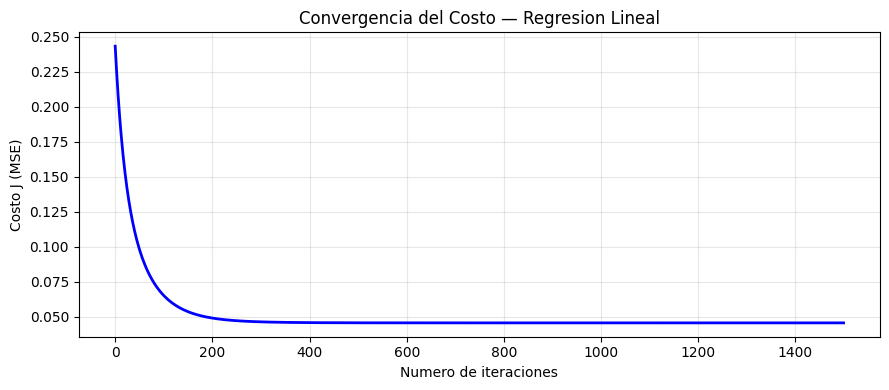

In [10]:
pyplot.figure(figsize=(9, 4))
pyplot.plot(np.arange(len(J_history_reg)), J_history_reg, 'b-', lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J (MSE)')
pyplot.title('Convergencia del Costo — Regresion Lineal')
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

### Evaluación del Modelo de Regresión

Para evaluar la regresión lineal en un problema de clasificación binaria, se convierte la salida
continua en 0 o 1 usando un umbral de 0.5: si la predicción es mayor a 0.5 se clasifica como 1.

Métricas:
- **MSE**: Error Cuadrático Medio en los datos de prueba
- **RMSE**: Raíz del MSE (misma unidad que y)
- **R²**: Qué tan bien explica el modelo la varianza de los datos (1 = perfecto)
- **Precisión**: porcentaje de aciertos al convertir la salida en clase 0 o 1

In [11]:
# Predicciones en entrenamiento y prueba
pred_tr_reg = X_tr_b.dot(theta_reg)
pred_te_reg = X_te_b.dot(theta_reg)

# Métricas de regresion
mse_train = np.mean((pred_tr_reg - y_tr) ** 2)
mse_test  = np.mean((pred_te_reg - y_te) ** 2)
rmse_test = np.sqrt(mse_test)

ss_res = np.sum((pred_te_reg - y_te) ** 2)
ss_tot = np.sum((y_te - np.mean(y_te)) ** 2)
r2     = 1 - (ss_res / ss_tot)

# Convertir salida continua a clase (umbral 0.5)
clase_tr_reg = (pred_tr_reg >= 0.5).astype(int)
clase_te_reg = (pred_te_reg >= 0.5).astype(int)
acc_train_reg = np.mean(clase_tr_reg == y_tr.astype(int)) * 100
acc_test_reg  = np.mean(clase_te_reg == y_te.astype(int)) * 100

print('=' * 50)
print('   MÉTRICAS — REGRESIÓN LINEAL')
print('=' * 50)
print(f'  MSE entrenamiento   : {mse_train:.4f}')
print(f'  MSE prueba          : {mse_test:.4f}')
print(f'  RMSE prueba         : {rmse_test:.4f}')
print(f'  R²  prueba          : {r2:.4f}')
print(f'  Precision train     : {acc_train_reg:.2f}%')
print(f'  Precision prueba    : {acc_test_reg:.2f}%')
print(f'  Diferencia overfitt : {abs(acc_train_reg - acc_test_reg):.2f}%')
print('=' * 50)

   MÉTRICAS — REGRESIÓN LINEAL
  MSE entrenamiento   : 0.0909
  MSE prueba          : 0.1261
  RMSE prueba         : 0.3551
  R²  prueba          : 0.4913
  Precision train     : 87.99%
  Precision prueba    : 83.14%
  Diferencia overfitt : 4.85%


### Visualización — Regresión Lineal

Se grafican las predicciones continuas del modelo comparadas con las etiquetas reales.
Un buen modelo debería agrupar las predicciones cerca de 0 para la clase 0 y cerca de 1 para la clase 1.

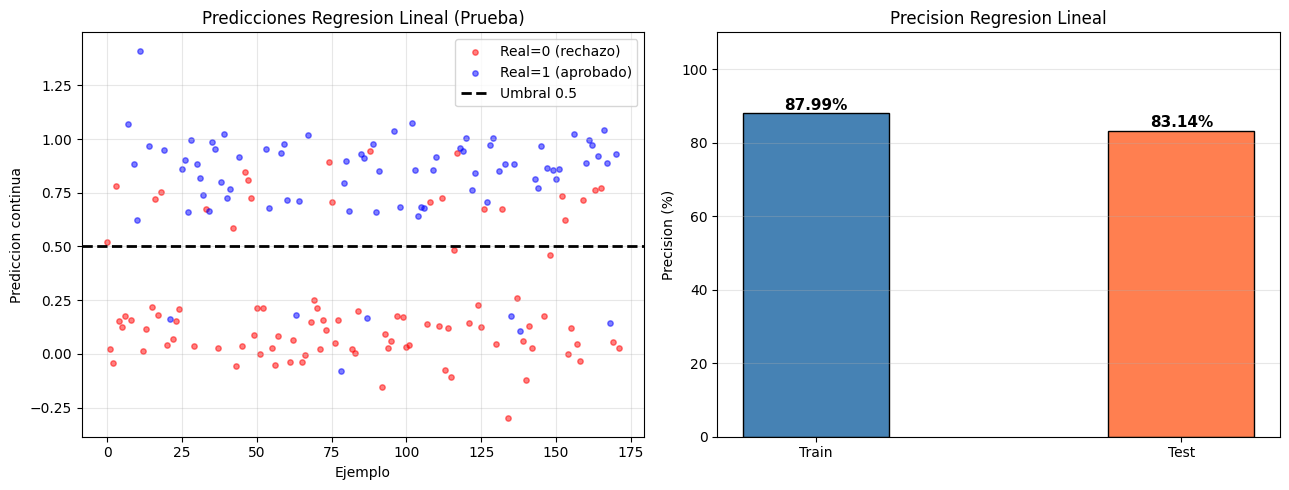

In [12]:
fig, axes = pyplot.subplots(1, 2, figsize=(13, 5))

# Gráfica 1: predicciones vs real
idx0 = np.where(y_te == 0)[0]
idx1 = np.where(y_te == 1)[0]
axes[0].scatter(idx0, pred_te_reg[idx0], c='red',  alpha=0.5, s=15, label='Real=0 (rechazo)')
axes[0].scatter(idx1, pred_te_reg[idx1], c='blue', alpha=0.5, s=15, label='Real=1 (aprobado)')
axes[0].axhline(y=0.5, color='black', linestyle='--', lw=2, label='Umbral 0.5')
axes[0].set_title('Predicciones Regresion Lineal (Prueba)')
axes[0].set_xlabel('Ejemplo')
axes[0].set_ylabel('Prediccion continua')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: precision train vs test
axes[1].bar(['Train', 'Test'], [acc_train_reg, acc_test_reg],
            color=['steelblue', 'coral'], edgecolor='black', width=0.4)
axes[1].set_ylim(0, 110)
axes[1].set_title('Precision Regresion Lineal')
axes[1].set_ylabel('Precision (%)')
for i, v in enumerate([acc_train_reg, acc_test_reg]):
    axes[1].text(i, v + 1, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

pyplot.tight_layout()
pyplot.show()

---
# Modelo 2 — Clasificación Logística Binaria

La regresión logística está diseñada específicamente para problemas de clasificación binaria.
A diferencia de la regresión lineal, su salida siempre está entre 0 y 1 gracias a la función sigmoide:

$$h_\theta(x) = g(\theta^T x) = \frac{1}{1+e^{-\theta^T x}}$$

La función de costo es la **Entropía Cruzada** con regularización L2:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1-y^{(i)}) \log(1-h_\theta(x^{(i)})) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2$$

### Funciones de Clasificación Logística

Se implementan `sigmoid` y `lrCostFunction` siguiendo exactamente el estilo del ingeniero.

In [13]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parametro para la regresion logistica
    regularizada y el gradiente del costo.
    """
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    J    = 0
    grad = np.zeros(theta.shape)

    h    = sigmoid(X.dot(theta.T))
    h    = np.clip(h, 1e-10, 1 - 1e-10)   # evitar log(0)

    temp    = theta.copy()
    temp[0] = 0   # no regularizar theta_0

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) \
        + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

### Entrenamiento del Modelo de Clasificación

Se usa `scipy.optimize.minimize` con el método **CG** (Gradiente Conjugado), igual que en los cuadernillos del ingeniero.
El clasificador binario entrena un solo vector $\theta$ para separar la clase 0 de la clase 1.

In [14]:
lambda_clf     = 0.1
maxiter_clf    = 200
costs_clf      = []

initial_theta_clf = np.zeros(n + 1)

print('Costo inicial:', lrCostFunction(initial_theta_clf, X_tr_b, y_tr, lambda_clf)[0])

def cost_wrapper_clf(theta):
    J, grad = lrCostFunction(theta, X_tr_b, y_tr, lambda_clf)
    costs_clf.append(J)
    return J, grad

res_clf = optimize.minimize(
    cost_wrapper_clf,
    initial_theta_clf,
    method='CG',
    jac=True,
    options={'maxiter': maxiter_clf}
)

theta_clf = res_clf.x
print(f'Costo final:   {costs_clf[-1]:.4f}')
print(f'theta shape:   {theta_clf.shape}')

Costo inicial: 0.6931471805599452
Costo final:   0.2837
theta shape:   (15,)


### Gráfica de Convergencia — Clasificación Logística

El costo de la entropía cruzada debe disminuir con cada iteración del optimizador.

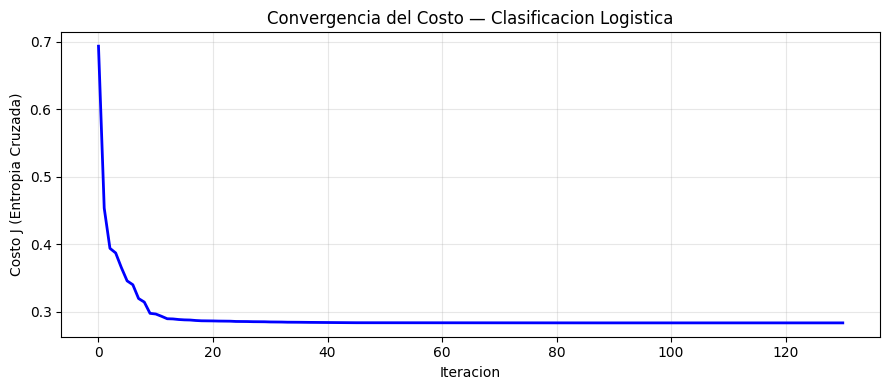

In [15]:
pyplot.figure(figsize=(9, 4))
pyplot.plot(np.arange(len(costs_clf)), costs_clf, 'b-', lw=2)
pyplot.xlabel('Iteracion')
pyplot.ylabel('Costo J (Entropia Cruzada)')
pyplot.title('Convergencia del Costo — Clasificacion Logistica')
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

### Evaluación del Modelo de Clasificación

Para evaluar el modelo usé métricas básicas de clasificación:
- Precisión global
- TP, FP, FN, TN
- Precision
- Recall
- F1-score

Con eso se puede ver no solo cuánto acierta, sino también en qué tipo de casos falla.

In [16]:
def predictLogistic(theta, X):
    m   = X.shape[0]
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)
    p   = (sigmoid(X_b.dot(theta)) >= 0.5).astype(int)
    return p

pred_tr_clf = predictLogistic(theta_clf, X_tr)
pred_te_clf = predictLogistic(theta_clf, X_te)

acc_train_clf = np.mean(pred_tr_clf == y_tr.astype(int)) * 100
acc_test_clf  = np.mean(pred_te_clf == y_te.astype(int)) * 100

# Métricas por clase (sin sklearn)
TP = np.sum((pred_te_clf == 1) & (y_te.astype(int) == 1))
FP = np.sum((pred_te_clf == 1) & (y_te.astype(int) == 0))
FN = np.sum((pred_te_clf == 0) & (y_te.astype(int) == 1))
TN = np.sum((pred_te_clf == 0) & (y_te.astype(int) == 0))

precision_clf = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_clf    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_clf        = 2 * (precision_clf * recall_clf) / (precision_clf + recall_clf) \
                if (precision_clf + recall_clf) > 0 else 0

print('=' * 50)
print('   MÉTRICAS — CLASIFICACIÓN LOGÍSTICA')
print('=' * 50)
print(f'  Precision train     : {acc_train_clf:.2f}%')
print(f'  Precision prueba    : {acc_test_clf:.2f}%')
print(f'  Diferencia overfitt : {abs(acc_train_clf - acc_test_clf):.2f}%')
print('-' * 50)
print(f'  TP (Verdaderos +)   : {TP}')
print(f'  FP (Falsos +)       : {FP}')
print(f'  FN (Falsos -)       : {FN}')
print(f'  TN (Verdaderos -)   : {TN}')
print('-' * 50)
print(f'  Precision           : {precision_clf:.4f}')
print(f'  Recall              : {recall_clf:.4f}')
print(f'  F1-Score            : {f1_clf:.4f}')
print('=' * 50)

   MÉTRICAS — CLASIFICACIÓN LOGÍSTICA
  Precision train     : 89.30%
  Precision prueba    : 84.30%
  Diferencia overfitt : 5.00%
--------------------------------------------------
  TP (Verdaderos +)   : 70
  FP (Falsos +)       : 19
  FN (Falsos -)       : 8
  TN (Verdaderos -)   : 75
--------------------------------------------------
  Precision           : 0.7865
  Recall              : 0.8974
  F1-Score            : 0.8383


### Visualización — Clasificación Logística

Aquí muestro tres cosas para entender mejor el resultado:
1. Matriz de confusión
2. Distribución de probabilidades
3. Comparación de precisión entre train y test

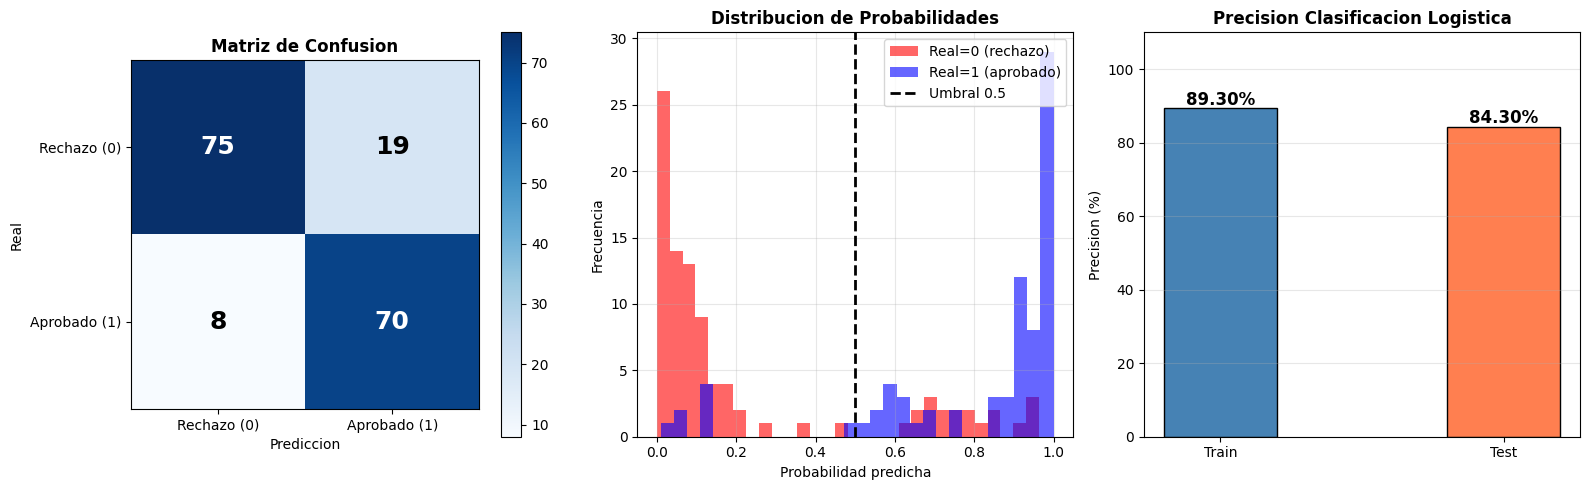

In [17]:
fig, axes = pyplot.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Matriz de confusión
conf_matrix = np.array([[TN, FP], [FN, TP]])
im = axes[0].imshow(conf_matrix, cmap='Blues')
etiquetas = ['Rechazo (0)', 'Aprobado (1)']
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(etiquetas)
axes[0].set_yticklabels(etiquetas)
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusion', fontweight='bold')
thresh = conf_matrix.max() / 2
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(conf_matrix[i, j]), ha='center', va='center',
                     fontsize=18, fontweight='bold',
                     color='white' if conf_matrix[i, j] > thresh else 'black')
pyplot.colorbar(im, ax=axes[0])

# Gráfica 2: Histograma de probabilidades
probs_te = sigmoid(X_te_b.dot(theta_clf))
axes[1].hist(probs_te[y_te == 0], bins=30, alpha=0.6, color='red',  label='Real=0 (rechazo)')
axes[1].hist(probs_te[y_te == 1], bins=30, alpha=0.6, color='blue', label='Real=1 (aprobado)')
axes[1].axvline(x=0.5, color='black', linestyle='--', lw=2, label='Umbral 0.5')
axes[1].set_title('Distribucion de Probabilidades', fontweight='bold')
axes[1].set_xlabel('Probabilidad predicha')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gráfica 3: Precision train vs test
axes[2].bar(['Train', 'Test'], [acc_train_clf, acc_test_clf],
            color=['steelblue', 'coral'], edgecolor='black', width=0.4)
axes[2].set_ylim(0, 110)
axes[2].set_title('Precision Clasificacion Logistica', fontweight='bold')
axes[2].set_ylabel('Precision (%)')
for i, v in enumerate([acc_train_clf, acc_test_clf]):
    axes[2].text(i, v + 1, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

pyplot.tight_layout()
pyplot.show()

### Predicciones sobre el conjunto de prueba

En esta parte comparo predicción vs valor real en una muestra de test para ver ejemplos concretos de aciertos y errores.

In [18]:
n_muestra = min(100, m_te)
X_muestra = X_te_b[:n_muestra]
y_muestra = y_te[:n_muestra].astype(int)
probs_muestra = sigmoid(X_muestra.dot(theta_clf))
pred_muestra  = (probs_muestra >= 0.5).astype(int)

print(f'{"Ej":>5s}{"Real":>12s}{"Predicho":>12s}{"Probabilidad":>15s}{"Correcto":>10s}')
print('-' * 56)
for i in range(20):
    real_lbl = 'Aprobado' if y_muestra[i] == 1 else 'Rechazo'
    pred_lbl = 'Aprobado' if pred_muestra[i] == 1 else 'Rechazo'
    correcto = 'SI' if pred_muestra[i] == y_muestra[i] else 'NO'
    print(f'{i+1:>5d}{real_lbl:>12s}{pred_lbl:>12s}{probs_muestra[i]:>15.4f}{correcto:>10s}')

print()
print(f'Precision sobre {n_muestra} ejemplos: {np.mean(pred_muestra == y_muestra)*100:.2f}%')

   Ej        Real    Predicho   Probabilidad  Correcto
--------------------------------------------------------
    1     Rechazo     Rechazo         0.2017        SI
    2     Rechazo     Rechazo         0.0287        SI
    3     Rechazo     Rechazo         0.0134        SI
    4     Rechazo    Aprobado         0.8369        NO
    5     Rechazo     Rechazo         0.0698        SI
    6     Rechazo     Rechazo         0.0734        SI
    7     Rechazo     Rechazo         0.0896        SI
    8    Aprobado    Aprobado         0.9904        SI
    9     Rechazo     Rechazo         0.0862        SI
   10    Aprobado    Aprobado         0.9249        SI
   11    Aprobado     Rechazo         0.4759        NO
   12    Aprobado    Aprobado         0.9999        SI
   13     Rechazo     Rechazo         0.0254        SI
   14     Rechazo     Rechazo         0.0720        SI
   15    Aprobado    Aprobado         0.9886        SI
   16     Rechazo     Rechazo         0.1773        SI
   17   

---
## Comparativa Final: Regresión Lineal vs Clasificación Logística

En esta sección comparo ambos modelos con las mismas métricas para ver cuál funciona mejor en este problema.

       COMPARATIVA DE MODELOS
Métrica                          Regresion   Logistica
------------------------------------------------------------
Precision Train (%)                  87.99       89.30
Precision Test (%)                   83.14       84.30
Diferencia (overfitting)              4.85        5.00
F1-Score (prueba)                      N/A      0.8383
R2 (prueba)                         0.4913         N/A


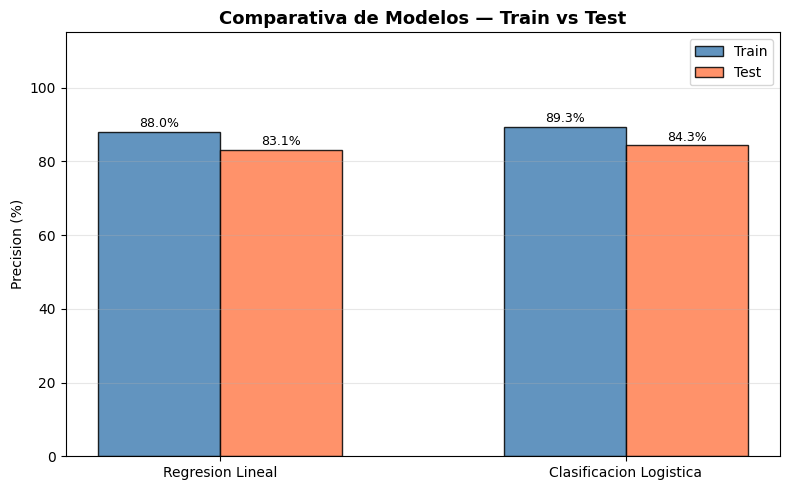

In [19]:
print('=' * 60)
print('       COMPARATIVA DE MODELOS')
print('=' * 60)
print(f'{"Métrica":<30s}{"Regresion":>12s}{"Logistica":>12s}')
print('-' * 60)
print(f'{"Precision Train (%)":<30s}{acc_train_reg:>12.2f}{acc_train_clf:>12.2f}')
print(f'{"Precision Test (%)":<30s}{acc_test_reg:>12.2f}{acc_test_clf:>12.2f}')
print(f'{"Diferencia (overfitting)":<30s}{abs(acc_train_reg-acc_test_reg):>12.2f}{abs(acc_train_clf-acc_test_clf):>12.2f}')
print(f'{"F1-Score (prueba)":<30s}{"N/A":>12s}{f1_clf:>12.4f}')
print(f'{"R2 (prueba)":<30s}{r2:>12.4f}{"N/A":>12s}')
print('=' * 60)

# Grafica comparativa
fig, ax = pyplot.subplots(figsize=(8, 5))
modelos = ['Regresion Lineal', 'Clasificacion Logistica']
acc_train_vals = [acc_train_reg, acc_train_clf]
acc_test_vals  = [acc_test_reg,  acc_test_clf]

x = np.arange(len(modelos))
w = 0.3
bars1 = ax.bar(x - w/2, acc_train_vals, w, label='Train', color='steelblue',  alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + w/2, acc_test_vals,  w, label='Test',  color='coral',      alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0, 115)
ax.set_ylabel('Precision (%)')
ax.set_title('Comparativa de Modelos — Train vs Test', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

pyplot.tight_layout()
pyplot.show()

---
## Conclusiones

Probé dos modelos con división 75/25: regresión lineal y clasificación logística.

La regresión lineal sirve como referencia, pero para este caso binario la logística funciona mejor porque entrega probabilidades entre 0 y 1 y está pensada para clasificar.

Además, para reducir sobreajuste usé:
- Regularización L2 en logística
- Balanceo del train
- Evaluación final sobre test no visto

En resumen, el modelo logístico fue la mejor opción para este dataset.

---
*SIS420 — Condori Romero Said*